## Setup Libraries

In [1]:
# !pip install -q uv

In [2]:
try:
    import ydf
except:
    !uv pip install ydf
    import ydf

print(f"ydf version: {ydf.__version__}")

ydf version: 0.15.0


In [3]:
import os, sys
import torch
import numpy as np, random
import pandas as pd

from colorama import Fore, Style
import matplotlib.pyplot as plt
import seaborn as sns
import gc

from importlib.metadata import version

## -- Machine Learning --
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import QuantileTransformer, OrdinalEncoder, LabelEncoder, KBinsDiscretizer, TargetEncoder

import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", 500)

## Load Data

In [4]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/test.csv")
orig = pd.read_csv("/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/EV_Adoption_and_Range_Anxiety_Dataset.csv")
submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv')

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Orig shape :", orig.shape)

train

Train shape: (668665, 15)
Test shape : (286571, 14)
Orig shape : (10000, 15)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,668660,30,71090.0,27.4,2,5,6,5.0,Male,Urban,Sedan,No,Yes,Medium,No
668661,668661,32,129990.0,5.0,2,5,4,1.0,Female,Suburban,SUV,Yes,Yes,Low,No
668662,668662,64,121791.0,24.2,1,5,6,1.0,Female,Suburban,Hatchback,Yes,Yes,Low,No
668663,668663,51,115923.0,43.7,2,0,0,1.0,Female,Rural,SUV,Yes,Yes,Low,No


## Preprocess Features

In [5]:
%%time

ID = 'id'
TARGET = 'Will_Buy_EV'
train[TARGET] = train[TARGET].map({'No': 0, 'Yes': 1})
orig[TARGET] = orig[TARGET].map({'No': 0, 'Yes': 1})
X = train.drop([ID, TARGET], axis=1); train_id = train[ID]
y = train[TARGET]
X_test = test.drop([ID], axis=1); test_id = test[ID]
del train, test
print("X      init shape:", X.shape)
print("X_test init shape:", X_test.shape, "\n")

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
print("init len(cat_cols):", len(cat_cols))
print("init len(num_cols):", len(num_cols), "\n")

category_map = {}
important_combos = [
    ('Annual_Income_USD', 'Range_Anxiety_Level'),
    ('Age', 'Range_Anxiety_Level'),
    ('Annual_Income_USD', 'Income_/_100_floor_'),
]
def feature_engineering(df, fit=False):
    # Fill NaNs
    for col in cat_cols:
        df[col] = df[col].fillna("missing")
    for col in num_cols:
        df[col] = df[col].fillna(0.0)

    # Categorize string cats
    for col in cat_cols:
        if fit:
            codes, uniques = df[col].factorize()
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = df[col].map(code_map).fillna(-1).astype('int32')
        df[col] = codes
        df[col] = df[col].astype('category')

    # Arithmetic interaction
    df['_Daily_Commute_km_/_Age'] = (df['Daily_Commute_km'] / (df['Age'] + 1e-6)).astype('float32')
    df['Income_/_100_floor_'] = np.floor(df['Annual_Income_USD'] / 100.0).astype('float32').astype('category')
    df['Income_/_1000_floor_'] = np.floor(df['Annual_Income_USD'] / 1000.0).astype('float32').astype('category')
    df['Income_/_10000_floor_'] = np.floor(df['Annual_Income_USD'] / 10000.0).astype('float32').astype('category')
    df['Daily_km_/_5_floor_'] = np.floor(df['Daily_Commute_km'] / 5.0).astype('float32').astype('category')

    # Categorize numericals
    for col in [i for i in num_cols if i not in ['Annual_Income_USD', 'Charging_Stations_Near_Home']]:
        cat_name = f"{col}_cat_"
        if fit:
            codes, uniques = np.floor(df[col]).factorize()
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = np.floor(df[col]).map(code_map).fillna(-1).astype('int32')
        df[cat_name] = codes
        df[cat_name] = df[cat_name].astype('category')

    # Digit extraction
    for col in ['Daily_Commute_km']:
        decimal_name = f"_{col}_decimal"
        df[decimal_name] = (df[col] % 1).round(2).astype('float32')
    df['Annual_Income_USD_is_multiple_10_'] = (np.floor(df['Annual_Income_USD']) % 10 == 0).astype('category')

    # Target encoding from orig
    for col in ['Annual_Income_USD']:
        orig_enc_name = f"_{col}_mean_target_orig"
        df[orig_enc_name] = (
            df[col]
            .map(orig.groupby(col)[TARGET].mean())
            .fillna(orig[TARGET].mean())
            .astype('float32')
        )

    # Count encoding
    for col in ['Annual_Income_USD']:
        count_name = f"_{col}_count"
        if fit:
            count_map = df[col].value_counts()
            category_map[count_name] = count_map
        else:
            count_map = category_map[count_name]
        df[count_name] = df[col].astype(object).map(count_map).fillna(0).astype('int32')

    # Discretize numericals
    bin_config = {'Annual_Income_USD': [400, 600, 800, 900, 1100]}
    for col, bins_list in bin_config.items():
        for n_bins in bins_list:
            for strategy in ['quantile']:
                bin_name = f"{col}_{n_bins}_{strategy}_bin_"
                if fit:
                    kb = KBinsDiscretizer(
                        n_bins=n_bins,
                        encode='ordinal',
                        strategy=strategy,
                        subsample=None
                    )
                    binned = kb.fit_transform(df[[col]]).ravel().astype('int32')
                    category_map[bin_name] = kb
                else:
                    kb = category_map[bin_name]
                    binned = kb.transform(df[[col]]).ravel().astype('int32')
                df[bin_name] = binned
                df[bin_name] = df[bin_name].astype('category')

    # Create interaction categories
    combo_names = []
    for cols in important_combos:
        combo_name = '_'.join(cols) + '_'
        combo_names.append(combo_name)
        combo_series = df[cols[0]].astype(str)
        for col in cols[1:]:
            combo_series = combo_series + '_' + df[col].astype(str)
        if fit:
            codes, uniques = pd.factorize(combo_series, sort=False)
            category_map[combo_name] = uniques
        else:
            uniques = category_map[combo_name]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = combo_series.map(code_map).fillna(-1).astype('int32')
        df[combo_name] = codes
        df[combo_name] = df[combo_name].astype('category')   

    new_cat_cols = [col for col in df.columns if col.endswith('_')]
    new_num_cols = [col for col in df.columns if col.startswith('_')]
    return df, new_cat_cols, new_num_cols, combo_names

X, new_cat_cols, new_num_cols, combo_names = feature_engineering(X, fit=True)
X_test, _, _, _ = feature_engineering(X_test, fit=False)
cat_cols += new_cat_cols; num_cols += new_num_cols
print("len(new_cat_cols):", len(new_cat_cols))
print("len(new_num_cols):", len(new_num_cols), "\n")

print("prep len(cat_cols):", len(cat_cols))
print("prep len(num_cols):", len(num_cols), "\n")
print("X      prep shape:", X.shape)
print("X_test prep shape:", X_test.shape, "\n")

X

X      init shape: (668665, 13)
X_test init shape: (286571, 13) 

init len(cat_cols): 6
init len(num_cols): 7 

len(new_cat_cols): 18
len(new_num_cols): 4 

prep len(cat_cols): 24
prep len(num_cols): 11 

X      prep shape: (668665, 35)
X_test prep shape: (286571, 35) 

CPU times: user 5.04 s, sys: 681 ms, total: 5.72 s
Wall time: 5.73 s


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,_Daily_Commute_km_/_Age,Income_/_100_floor_,Income_/_1000_floor_,Income_/_10000_floor_,Daily_km_/_5_floor_,Age_cat_,Daily_Commute_km_cat_,Number_of_Cars_Owned_cat_,Charging_Stations_Near_Work_cat_,Environmental_Concern_Level_cat_,_Daily_Commute_km_decimal,Annual_Income_USD_is_multiple_10_,_Annual_Income_USD_mean_target_orig,_Annual_Income_USD_count,Annual_Income_USD_400_quantile_bin_,Annual_Income_USD_600_quantile_bin_,Annual_Income_USD_800_quantile_bin_,Annual_Income_USD_900_quantile_bin_,Annual_Income_USD_1100_quantile_bin_,Annual_Income_USD_Range_Anxiety_Level_,Age_Range_Anxiety_Level_,Annual_Income_USD_Income_/_100_floor__
0,66,92887.0,23.4,2,3,7,1.0,0,0,0,0,0,0,0.354545,928.0,92.0,9.0,4.0,0,0,0,0,0,0.4,False,0.000000,96,214,321,427,482,584,0,0,0
1,38,30000.0,5.0,1,2,2,4.0,0,1,1,0,0,0,0.131579,300.0,30.0,3.0,1.0,1,1,1,1,1,0.0,True,0.066427,61605,0,0,0,0,0,1,1,1
2,26,94389.0,36.8,1,8,15,5.0,1,2,0,1,1,0,1.415385,943.0,94.0,9.0,7.0,2,2,1,2,2,0.8,False,1.000000,45,225,336,448,505,612,2,2,2
3,66,73580.0,23.7,2,6,9,3.0,0,0,2,0,0,0,0.359091,735.0,73.0,7.0,4.0,0,0,0,3,3,0.7,True,1.000000,177,96,144,191,216,262,3,0,3
4,54,57898.0,50.8,1,2,3,3.0,0,0,2,0,0,0,0.940741,578.0,57.0,5.0,10.0,3,3,1,4,3,0.8,False,0.500000,290,27,40,53,60,73,4,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,0,2,0,1,1,1,0.913333,710.0,71.0,7.0,5.0,39,9,0,19,2,0.4,True,1.000000,81,80,119,159,180,218,9486,47,6094
668661,32,129990.0,5.0,2,5,4,1.0,1,0,1,0,1,0,0.156250,1299.0,129.0,12.0,1.0,15,1,0,18,0,0.0,True,0.000000,82,338,506,675,760,925,161,19,160
668662,64,121791.0,24.2,1,5,6,1.0,1,0,2,0,1,0,0.378125,1217.0,121.0,12.0,4.0,37,44,1,19,0,0.2,False,0.000000,175,321,480,640,721,876,3076,45,2836
668663,51,115923.0,43.7,2,0,0,1.0,1,1,1,0,1,0,0.856863,1159.0,115.0,11.0,8.0,13,41,0,15,0,0.7,False,0.175000,2,307,459,612,689,838,14312,16,9197


In [6]:
X.nunique()

Age                                          45
Annual_Income_USD                         13214
Daily_Commute_km                            805
Number_of_Cars_Owned                          4
Charging_Stations_Near_Home                  15
Charging_Stations_Near_Work                  20
Environmental_Concern_Level                   5
Gender                                        3
City_Type                                     3
Current_Car_Type                              4
Home_Charging_Possible                        2
Subsidy_Available                             2
Range_Anxiety_Level                           3
_Daily_Commute_km_/_Age                   22554
Income_/_100_floor_                        1142
Income_/_1000_floor_                        150
Income_/_10000_floor_                        16
Daily_km_/_5_floor_                          19
Age_cat_                                     45
Daily_Commute_km_cat_                        89
Number_of_Cars_Owned_cat_               

In [7]:
# %%time 

# ## -- Search HPO space in 'LOCAL' & 'BEST_FIRST_GLOBAL' -- 
# MODEL_NAME = 'YDFsearch'
# FOLDS = 3

# print(f"\n🚀 Training {MODEL_NAME} with {FOLDS} Folds...")

# X = train[FEATURES]
# y = train[TARGET].astype(int)
# X_test = test[FEATURES]

# skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)
# oof_preds  = np.zeros(len(train))
# test_preds = np.zeros(len(test))

# # feature_importances = pd.DataFrame()
# ydf_models = []

# for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
#     X_train, y_train = X.iloc[train_idx].copy(), y.iloc[train_idx]
#     X_valid, y_valid = X.iloc[valid_idx].copy(), y.iloc[valid_idx]
#     # X_test_fold = X_test.copy()

#     # Triple Sklearn Target Encoders (Auto, Strict 10, and Massive 100)
#     te_auto = TargetEncoder(shuffle=True, cv=5, smooth='auto', random_state=42)
#     te_10   = TargetEncoder(shuffle=True, cv=5, smooth=10.0, random_state=42)
#     te_100  = TargetEncoder(shuffle=True, cv=5, smooth=100.0, random_state=42)

#     X_train_enc_auto = te_auto.fit_transform(X_train[TARGET_ENCODE_COLS], y_train)
#     X_valid_enc_auto = te_auto.transform(X_valid[TARGET_ENCODE_COLS])
#     # X_test_enc_auto  = te_auto.transform(X_test_fold[TARGET_ENCODE_COLS])

#     X_train_enc_10 = te_10.fit_transform(X_train[TARGET_ENCODE_COLS], y_train)
#     X_valid_enc_10 = te_10.transform(X_valid[TARGET_ENCODE_COLS])
#     # X_test_enc_10  = te_10.transform(X_test_fold[TARGET_ENCODE_COLS])

#     X_train_enc_100 = te_100.fit_transform(X_train[TARGET_ENCODE_COLS], y_train)
#     X_valid_enc_100 = te_100.transform(X_valid[TARGET_ENCODE_COLS])
#     # X_test_enc_100  = te_100.transform(X_test_fold[TARGET_ENCODE_COLS])

#     for i, col in enumerate(TARGET_ENCODE_COLS):
#         # Auto smoothing TE
#         X_train[f"{col}_TE_auto"] = X_train_enc_auto[:, i].astype('float32')
#         X_valid[f"{col}_TE_auto"] = X_valid_enc_auto[:, i].astype('float32')
#         # X_test_fold[f"{col}_TE_auto"] = X_test_enc_auto[:, i].astype('float32')

#         # Strict (10.0) smoothing TE
#         X_train[f"{col}_TE_10"] = X_train_enc_10[:, i].astype('float32')
#         X_valid[f"{col}_TE_10"] = X_valid_enc_10[:, i].astype('float32')
#         # X_test_fold[f"{col}_TE_10"] = X_test_enc_10[:, i].astype('float32')

#         # Massive (100.0) smoothing TE (Markus's method)
#         X_train[f"{col}_TE_100"] = X_train_enc_100[:, i].astype('float32')
#         X_valid[f"{col}_TE_100"] = X_valid_enc_100[:, i].astype('float32')
#         # X_test_fold[f"{col}_TE_100"] = X_test_enc_100[:, i].astype('float32')

#         # Drop the original string column
#         X_train.drop(columns=[col], inplace=True)
#         X_valid.drop(columns=[col], inplace=True)
#         # X_test_fold.drop(columns=[col], inplace=True)

#     # APPLY DYNAMIC PRUNING
#     if len(features_to_drop) > 0:
#         # Check X_train.columns because it contains both base features and the new _TE_ features
#         safe_to_drop = [c for c in features_to_drop if c in X_train.columns]

#         if len(safe_to_drop) > 0:
#             if fold == 1:
#                 print(f"   -> Successfully pruned {len(safe_to_drop)} features.")

#             X_train.drop(columns=safe_to_drop, inplace=True, errors='ignore')
#             X_valid.drop(columns=safe_to_drop, inplace=True, errors='ignore')
#             # X_test_fold.drop(columns=safe_to_drop, inplace=True, errors='ignore')

#     if fold == 1:
#         display(X_train.head())

#     tuner = ydf.RandomSearchTuner(num_trials=30, automatic_search_space=False)
#     # tuner.choice('num_trees', [5000, 2000])
#     # tuner.choice('shrinkage', [0.02, 0.05]) 
#     # tuner.choice('subsample', [0.9, 1.0])
#     tuner.choice('categorical_algorithm', ['CART', 'RANDOM']) #'CART', 'RANDOM', 'ONE_HOT'
#     tuner.choice('l2_regularization', [0.0, 0.1, 0.5])

#     ## -- 'LOCAL' acts like 'depthwise': uses 'max_depth' --
#     local_subspace = tuner.choice('growing_strategy', ['LOCAL'])
#     local_subspace.choice('max_depth', [4, 5, 6, 8])

#     ## -- 'BEST_FIRST_GLOBAL' acts like 'lossguide': uses 'max_num_nodes' --
#     global_subspace = tuner.choice('growing_strategy', ['BEST_FIRST_GLOBAL'], merge=True)
#     # global_subspace.choice('max_num_nodes', [None, 32, 64, 128])

#     # ## -- Enable ydf process numeric features as categories --
#     # num_as_cat = []
#     # for f in CATS:
#     #     num_as_cat.append(ydf.Feature(f, ydf.Semantic.CATEGORICAL))

#     ydf_HPO_model = ydf.GradientBoostedTreesLearner(
#         task=ydf.Task.CLASSIFICATION,
#         label=TARGET, 
#         tuner=tuner,
#         num_trees=1000,
#         shrinkage=0.1,
#         # class_weights=get_class_weights(train_data[TARGET]), ## 
#         # max_depth=4,
#         # features=num_as_cat,
#         # include_all_columns=True,
#         # l2_regularization=0.15,
#         # categorical_algorithm='RANDOM',
#         # early_stopping_initial_iteration=10,
#         early_stopping_num_trees_look_ahead=50,
#         random_seed=42, 
#         num_threads=3, 
#     ).train(pd.concat([X_train, y_train], axis=1), verbose=1)
    
#     ydf_models.append(ydf_HPO_model)

In [8]:
# ydf_models[0].describe()

In [9]:
# ydf_models[1].describe()

In [10]:
# ydf_models[2].describe()

## Config

In [11]:
# -- TUNED YDF MODEL --
local_params = {
    'task': ydf.Task.CLASSIFICATION,
    'growing_strategy': "LOCAL",
    'num_trees': 1500, # def=300
    'max_depth': 4,
    'shrinkage': 0.06, # def=0.1
    'categorical_algorithm': "CART", # "CART", "RANDOM", 'ONE_HOT'
    'sampling_method': 'GOSS', # 'RANDOM', 'GOSS', 'SELGB'
    # 'split_axis': , # 'AXIS_ALIGNED', 'SPARSE_OBLIQUE', 'MHLD_OBLIQUE'
    # 'subsample': 0.95, # default RANDOM sampling
    # 'goss_alpha': 0.2, # activates GOSS sampling
    # 'l2_regularization': 1.0,
    # 'early_stopping': 'NONE', # 'NONE', 'MIN_LOSS_FINAL', 'LOSS_INCREASE'
    # 'early_stopping_initial_iteration': 10,
    # 'min_examples': 10,
    # 'num_discretized_numerical_bins': 1024,
    'early_stopping_num_trees_look_ahead': 100,
    'random_seed': 42,
}

global_params = {
    'task': ydf.Task.CLASSIFICATION,
    'growing_strategy': "BEST_FIRST_GLOBAL",
    'num_trees': 1500,
    # 'max_num_nodes': None,
    'shrinkage': 0.03,
    'categorical_algorithm': 'CART', # 'CART', 'RANDOM', 'ONE_HOT'
    'sampling_method': 'GOSS', # 'RANDOM', 'GOSS', 'SELGB'
    # 'split_axis': , # 'AXIS_ALIGNED', 'SPARSE_OBLIQUE', 'MHLD_OBLIQUE'
    # 'subsample': 0.95, # default RANDOM sampling
    # 'goss_alpha': 0.2, # activates GOSS sampling
    'l2_regularization': 0.0,
    # 'early_stopping': 'MIN_LOSS_FINAL', # NONE, MIN_LOSS_FINAL, LOSS_INCREASE
    # 'early_stopping_initial_iteration': 10,
    # 'min_examples': 10,
    # 'num_discretized_numerical_bins': 1024,
    'early_stopping_num_trees_look_ahead': 100,
    'random_seed': 42,
}

all_models = {
    'local': ('YDF_LCL', local_params),
    'global': ('YDF_GLB', global_params),
}

print("🤖 Model parameters defined!")

all_models

🤖 Model parameters defined!


{'local': ('YDF_LCL',
  {'task': <Task.CLASSIFICATION: 'CLASSIFICATION'>,
   'growing_strategy': 'LOCAL',
   'num_trees': 1500,
   'max_depth': 4,
   'shrinkage': 0.06,
   'categorical_algorithm': 'CART',
   'sampling_method': 'GOSS',
   'early_stopping_num_trees_look_ahead': 100,
   'random_seed': 42}),
 'global': ('YDF_GLB',
  {'task': <Task.CLASSIFICATION: 'CLASSIFICATION'>,
   'growing_strategy': 'BEST_FIRST_GLOBAL',
   'num_trees': 1500,
   'shrinkage': 0.03,
   'categorical_algorithm': 'CART',
   'sampling_method': 'GOSS',
   'l2_regularization': 0.0,
   'early_stopping_num_trees_look_ahead': 100,
   'random_seed': 42})}

In [12]:
USE_FULL_TRAIN = True

x_sample, x_sample2 = train_test_split(pd.concat([X, y], axis=1), train_size=300_000, stratify=y, random_state=0)
train_X = pd.concat([X, y], axis=1).copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True)

print(train_X.shape)
train_X

(668665, 36)


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,_Daily_Commute_km_/_Age,Income_/_100_floor_,Income_/_1000_floor_,Income_/_10000_floor_,Daily_km_/_5_floor_,Age_cat_,Daily_Commute_km_cat_,Number_of_Cars_Owned_cat_,Charging_Stations_Near_Work_cat_,Environmental_Concern_Level_cat_,_Daily_Commute_km_decimal,Annual_Income_USD_is_multiple_10_,_Annual_Income_USD_mean_target_orig,_Annual_Income_USD_count,Annual_Income_USD_400_quantile_bin_,Annual_Income_USD_600_quantile_bin_,Annual_Income_USD_800_quantile_bin_,Annual_Income_USD_900_quantile_bin_,Annual_Income_USD_1100_quantile_bin_,Annual_Income_USD_Range_Anxiety_Level_,Age_Range_Anxiety_Level_,Annual_Income_USD_Income_/_100_floor__,Will_Buy_EV
0,66,92887.0,23.4,2,3,7,1.0,0,0,0,0,0,0,0.354545,928.0,92.0,9.0,4.0,0,0,0,0,0,0.4,False,0.000000,96,214,321,427,482,584,0,0,0,0
1,38,30000.0,5.0,1,2,2,4.0,0,1,1,0,0,0,0.131579,300.0,30.0,3.0,1.0,1,1,1,1,1,0.0,True,0.066427,61605,0,0,0,0,0,1,1,1,0
2,26,94389.0,36.8,1,8,15,5.0,1,2,0,1,1,0,1.415385,943.0,94.0,9.0,7.0,2,2,1,2,2,0.8,False,1.000000,45,225,336,448,505,612,2,2,2,1
3,66,73580.0,23.7,2,6,9,3.0,0,0,2,0,0,0,0.359091,735.0,73.0,7.0,4.0,0,0,0,3,3,0.7,True,1.000000,177,96,144,191,216,262,3,0,3,0
4,54,57898.0,50.8,1,2,3,3.0,0,0,2,0,0,0,0.940741,578.0,57.0,5.0,10.0,3,3,1,4,3,0.8,False,0.500000,290,27,40,53,60,73,4,3,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,0,2,0,1,1,1,0.913333,710.0,71.0,7.0,5.0,39,9,0,19,2,0.4,True,1.000000,81,80,119,159,180,218,9486,47,6094,0
668661,32,129990.0,5.0,2,5,4,1.0,1,0,1,0,1,0,0.156250,1299.0,129.0,12.0,1.0,15,1,0,18,0,0.0,True,0.000000,82,338,506,675,760,925,161,19,160,0
668662,64,121791.0,24.2,1,5,6,1.0,1,0,2,0,1,0,0.378125,1217.0,121.0,12.0,4.0,37,44,1,19,0,0.2,False,0.000000,175,321,480,640,721,876,3076,45,2836,0
668663,51,115923.0,43.7,2,0,0,1.0,1,1,1,0,1,0,0.856863,1159.0,115.0,11.0,8.0,13,41,0,15,0,0.7,False,0.175000,2,307,459,612,689,838,14312,16,9197,0


## Train K-Fold

In [13]:
%%time

_model = 'local'
MODEL_NAME = all_models[_model][0]

USE_TE = True
FOLDS  = 10
print(f"\n🚀 Training {MODEL_NAME} with {FOLDS } folds...")

X_1 = train_X.drop([TARGET], axis=1)
y_1 = train_X[TARGET]

skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X_1))
test_preds = np.zeros(len(X_test))

fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_1, y_1), 1):
    X_tr, X_val = X_1.iloc[tr_idx].copy(), X_1.iloc[val_idx].copy()
    y_tr, y_val = y_1.iloc[tr_idx], y_1.iloc[val_idx]
    X_tst = X_test.copy()  

    # Target encoding
    if USE_TE:
        te_cols = combo_names
        print(f"Target encoding ({len(te_cols)}) features")
        TE = TargetEncoder(cv=5, smooth='auto', shuffle=True, random_state=42)
        tr_enc = TE.fit_transform(X_tr[te_cols], y_tr)
        val_enc = TE.transform(X_val[te_cols])
        tst_enc = TE.transform(X_tst[te_cols])

        te_names = [f"_{col}TE" for col in te_cols]
        X_tr[te_names]  = tr_enc
        X_val[te_names] = val_enc
        X_tst[te_names] = tst_enc

    # if fold == 1: print("len(FEATURES):", len(X_tr.columns.tolist()), "\n")
    print("-"*55)
    print(f"### Fold {fold}/{FOLDS}", end=" | "); print(f"train={X_tr.shape}, valid={X_val.shape}")
    print("-"*55)

    use_params = all_models[_model][1]
    model = ydf.GradientBoostedTreesLearner(
        **use_params,
        label=TARGET,
        # class_weights=get_class_weights(y_train) if use_weights else None,
        # features=flat_features,   # 1. Semantic for categories goes here
        # include_all_columns=True, # 2. Include all features for training
    ).train(
        ds=pd.concat([X_tr, y_tr], axis=1),
        valid=pd.concat([X_val, y_val], axis=1),
        verbose=1,
    )

    oof_preds[val_idx] = model.predict(X_val)
    test_preds += model.predict(X_tst) / FOLDS

    fold_score = roc_auc_score(y_val, oof_preds[val_idx])
    fold_scores.append(fold_score)
    print(f"{Fore.YELLOW}{Style.BRIGHT} -> Fold {fold} | AUC: {fold_score:.6f}{Style.RESET_ALL}\n")

oof_auc = np.round(roc_auc_score(y_1, oof_preds), 6)

## - CV summary -  
print('\n'+'='*50)
print(f"{FOLDS}-FOLD CV: {MODEL_NAME} | Features used: {X_tr.shape[1]}")
print('='*50)
for i, score in enumerate(fold_scores, 1):  
    print(f" • Fold {i} AUC: {score:.6f}")  

print('-'*50)
print(f"OOF AUC: {Fore.BLUE}{Style.BRIGHT}{oof_auc}{Style.RESET_ALL}")
print(f"AVG AUC: {Fore.BLUE}{Style.BRIGHT}{np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}{Style.RESET_ALL}")   
print("-"*50)


🚀 Training YDF_LCL with 10 folds...
Target encoding (3) features
-------------------------------------------------------
### Fold 1/10 | train=(601798, 38), valid=(66867, 38)
-------------------------------------------------------
Train model on 601798 training examples and 66867 validation examples
Model trained in 0:12:31.829311
 -> Fold 1 | AUC: 0.944576

Target encoding (3) features
-------------------------------------------------------
### Fold 2/10 | train=(601798, 38), valid=(66867, 38)
-------------------------------------------------------
Train model on 601798 training examples and 66867 validation examples
Model trained in 0:11:13.442052
 -> Fold 2 | AUC: 0.944825

Target encoding (3) features
-------------------------------------------------------
### Fold 3/10 | train=(601798, 38), valid=(66867, 38)
-------------------------------------------------------
Train model on 601798 training examples and 66867 validation examples
Model trained in 0:11:05.994785
 -> Fold 3 | AUC

In [14]:
# ==================================================
# 3-FOLD CV: ydf_LCL | Features used: 38
# ==================================================
#  • Fold 1 AUC: 0.943994
#  • Fold 2 AUC: 0.943625
#  • Fold 3 AUC: 0.942828
# --------------------------------------------------
# OOF AUC: 0.943458
# AVG AUC: 0.943483 ± 0.000487
# --------------------------------------------------
# CPU times: user 22min 42s, sys: 18.3 s, total: 23min
# Wall time: 6min 56s

# ==================================================
# 3-FOLD CV: YDF_GLB | Features used: 38
# ==================================================
#  • Fold 1 AUC: 0.943810
#  • Fold 2 AUC: 0.943360
#  • Fold 3 AUC: 0.942624
# --------------------------------------------------
# OOF AUC: 0.943223
# AVG AUC: 0.943265 ± 0.000489
# --------------------------------------------------
# CPU times: user 40min 12s, sys: 1min, total: 41min 13s
# Wall time: 12min 33s

## - CV summary -  
print('\n'+'='*50)
print(f"{FOLDS}-FOLD CV: {MODEL_NAME} | Features used: {X_tr.shape[1]}")
print('='*50)
for i, score in enumerate(fold_scores, 1):  
    print(f" • Fold {i} AUC: {score:.6f}")  

print('-'*50)
print(f"OOF AUC: {Fore.BLUE}{Style.BRIGHT}{oof_auc}{Style.RESET_ALL}")
print(f"AVG AUC: {Fore.BLUE}{Style.BRIGHT}{np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}{Style.RESET_ALL}")   
print("-"*50)


10-FOLD CV: YDF_LCL | Features used: 38
 • Fold 1 AUC: 0.944576
 • Fold 2 AUC: 0.944825
 • Fold 3 AUC: 0.945053
 • Fold 4 AUC: 0.945746
 • Fold 5 AUC: 0.946576
 • Fold 6 AUC: 0.946631
 • Fold 7 AUC: 0.945359
 • Fold 8 AUC: 0.946272
 • Fold 9 AUC: 0.946611
 • Fold 10 AUC: 0.944770
--------------------------------------------------
OOF AUC: 0.94564
AVG AUC: 0.945642 ± 0.000787
--------------------------------------------------


In [15]:
# model.analyze(pd.concat([X_val, y_val], axis=1))

## Evaluation and Submission

In [16]:
_NAME = f"{MODEL_NAME}({X_tr.shape[1]})_{oof_auc}"

# Save OOF Predictions (for ensembling meta-model)
# oof_df = pd.DataFrame({'id': train['id'], 'OOF_Pred': oof_preds})
# oof_df.to_csv(f'oof_{MODEL_NAME}.csv', index=False)
np.save(f"oof_{_NAME}.npy", oof_preds)
print(f"💾 Saved 'oof_{_NAME}.npy'")

# Save Raw Test Predictions (for ensembling)
# test_df = pd.DataFrame({'id': test['id'], TARGET: test_preds})
# test_df.to_csv(f'test_{MODEL_NAME}.csv', index=False)
np.save(f"test_{_NAME}.npy", test_preds)
print(f"💾 Saved 'test_{_NAME}.npy'")

# Save Kaggle Submission (Averaged Test Predictions)
submission[TARGET] = test_preds
submission.to_csv(f"submission_{_NAME}.csv", index=False)
print(f"💾 Saved 'submission_{_NAME}.csv'")

print()
submission

💾 Saved 'oof_YDF_LCL(38)_0.94564.npy'
💾 Saved 'test_YDF_LCL(38)_0.94564.npy'
💾 Saved 'submission_YDF_LCL(38)_0.94564.csv'



,id,Will_Buy_EV
0,668665,0.024786
1,668666,0.007029
2,668667,0.004854
3,668668,0.003121
4,668669,0.024907
...,...,...
286566,955231,0.001254
286567,955232,0.273339
286568,955233,0.001281
286569,955234,0.001738


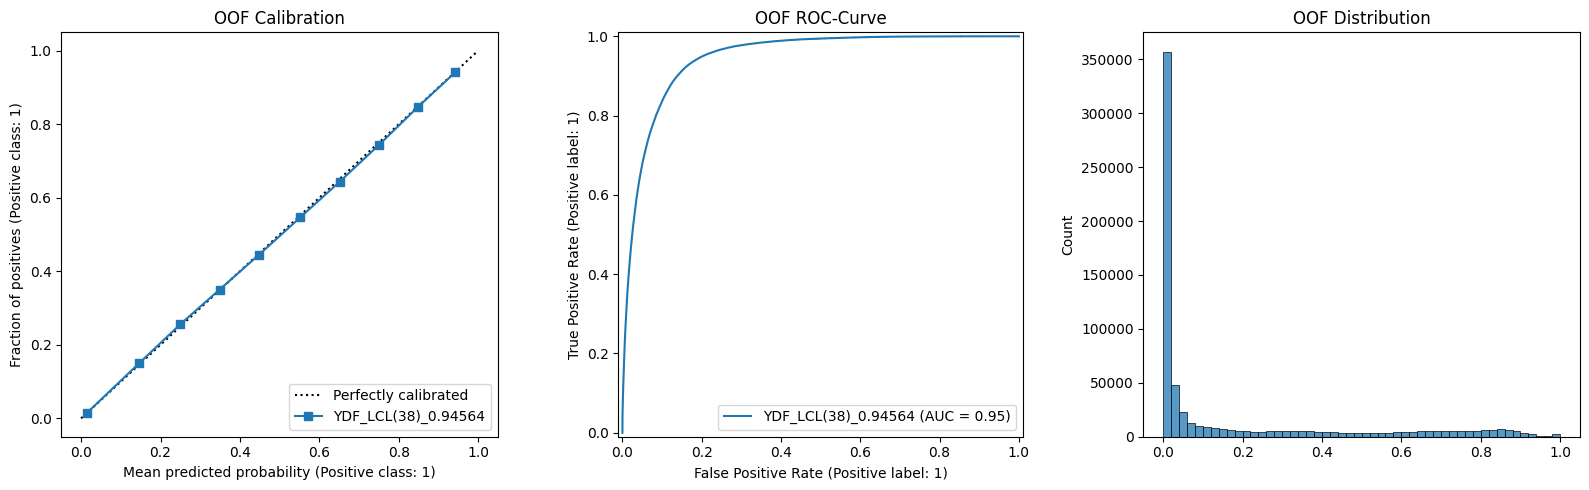

In [17]:
## -- Plot oof distributions --
_, axs = plt.subplots(1, 3, figsize=(16, 5))

CalibrationDisplay.from_predictions(y_1, oof_preds, n_bins=10, name=_NAME, ax=axs[0])
axs[0].set_title(f"OOF Calibration")

RocCurveDisplay.from_predictions(y_1, oof_preds, name=_NAME, ax=axs[1])
axs[1].set_title(f"OOF ROC-Curve")

sns.histplot(oof_preds, ax=axs[2], bins=50)
axs[2].set_title(f"OOF Distribution")

plt.tight_layout()
plt.show()

In [18]:
# !rm -r /kaggle/working/